In [1]:
from pathlib import Path
import rasterio
from src.preprocessing import *
from src.config import *
from src.mosaic import *
from src.clipping import *

### Reproject every scene into one CRS (EPSG:32644, UTM Zone 44N) 

In [2]:
batch_reproject(
    ROOT / "data" / "raw" / "satellite",
    ROOT / "data" / "processed" / "reprojected",
    years=[2016, 2022, 2025],
)

Reprojecting Scene1/BAND4.tif
Reprojecting Scene1/BAND5.tif
Reprojecting Scene1/BAND2.tif
Reprojecting Scene1/BAND3.tif
Reprojecting Scene3/BAND4.tif
Reprojecting Scene3/BAND5.tif
Reprojecting Scene3/BAND2.tif
Reprojecting Scene3/BAND3.tif
Reprojecting Scene2/BAND4.tif
Reprojecting Scene2/BAND5.tif
Reprojecting Scene2/BAND2.tif
Reprojecting Scene2/BAND3.tif
Reprojecting Scene1/BAND4.tif
Reprojecting Scene1/BAND5.tif
Reprojecting Scene1/BAND2.tif
Reprojecting Scene1/BAND3.tif
Reprojecting Scene3/BAND4.tif
Reprojecting Scene3/BAND5.tif
Reprojecting Scene3/BAND2.tif
Reprojecting Scene3/BAND3.tif
Reprojecting Scene2/BAND4.tif
Reprojecting Scene2/BAND5.tif
Reprojecting Scene2/BAND2.tif
Reprojecting Scene2/BAND3.tif
Reprojecting Scene1/BAND4.tif
Reprojecting Scene1/BAND5.tif
Reprojecting Scene1/BAND2.tif
Reprojecting Scene1/BAND3.tif
Reprojecting Scene3/BAND4.tif
Reprojecting Scene3/BAND5.tif
Reprojecting Scene3/BAND2.tif
Reprojecting Scene3/BAND3.tif
Reprojecting Scene2/BAND4.tif
Reprojecti

Verify Output

In [3]:
sample_files = list((ROOT / "data" / "processed" / "reprojected").rglob("*.tif"))

print(f"\nCreated {len(sample_files)} reprojected rasters.")

if sample_files:
    
    sample = sample_files[0]

    with rasterio.open(sample) as src:
        print("\nSample:", sample)
        print("CRS:", src.crs)
        print("Size:", src.width, "x", src.height)


Created 36 reprojected rasters.

Sample: /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/data/processed/reprojected/2022/Scene1/BAND4.tif
CRS: EPSG:32644
Size: 7985 x 7179


### Band-wise mosaics for different scenes

In [5]:
YEARS = [2016, 2022, 2025]

BANDS = [
    "BAND2",
    "BAND3",
    "BAND4",
    "BAND5",
]

batch_mosaic(
    ROOT / "data" / "processed" / "reprojected",
    ROOT / "data" / "processed" / "mosaics",
    YEARS,
    BANDS,
)


Processing 2016
  BAND2: 3 scenes
  BAND3: 3 scenes
  BAND4: 3 scenes
  BAND5: 3 scenes

Processing 2022
  BAND2: 3 scenes
  BAND3: 3 scenes
  BAND4: 3 scenes
  BAND5: 3 scenes

Processing 2025
  BAND2: 3 scenes
  BAND3: 3 scenes
  BAND4: 3 scenes
  BAND5: 3 scenes


Verify Output

In [6]:
sample = next((ROOT / "data" / "processed" / "mosaics").rglob("BAND4.tif"))

with rasterio.open(sample) as src:
    print("File:", sample.name)
    print("CRS:", src.crs)
    print("Bands:", src.count)
    print("Shape:", src.width, "x", src.height)
    print("Bounds:", src.bounds)

File: BAND4.tif
CRS: EPSG:32644
Bands: 1
Shape: 12256 x 12965
Bounds: BoundingBox(left=83641.01398992387, bottom=3204828.000041886, right=377785.0139907571, top=3515988.0000427677)


### Clip the mosaics to fit study area only

In [2]:
YEARS = [2016, 2022, 2025]

BANDS = [
    "BAND2",
    "BAND3",
    "BAND4",
    "BAND5",
]

batch_clip(
    ROOT / "data" / "processed" / "mosaics",
    ROOT / "data" / "processed" / "study_districts.gpkg",
    ROOT / "data" / "processed" / "clipped",
    YEARS,
    BANDS,
)


Processing 2016
  Clipping BAND2
  Clipping BAND3
  Clipping BAND4
  Clipping BAND5

Processing 2022
  Clipping BAND2
  Clipping BAND3
  Clipping BAND4
  Clipping BAND5

Processing 2025
  Clipping BAND2
  Clipping BAND3
  Clipping BAND4
  Clipping BAND5


In [3]:
sample = next(
    (ROOT / "data" / "processed" / "clipped").rglob("BAND4.tif")
)

with rasterio.open(sample) as src:
    print("File:", sample.name)
    print("CRS:", src.crs)
    print("Size:", src.width, "x", src.height)
    print("Bands:", src.count)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)

File: BAND4.tif
CRS: EPSG:32644
Size: 6614 x 7489
Bands: 1
Bounds: BoundingBox(left=170665.01399017038, bottom=3257892.0000420366, right=329401.01399062003, top=3437628.0000425456)
NoData: None


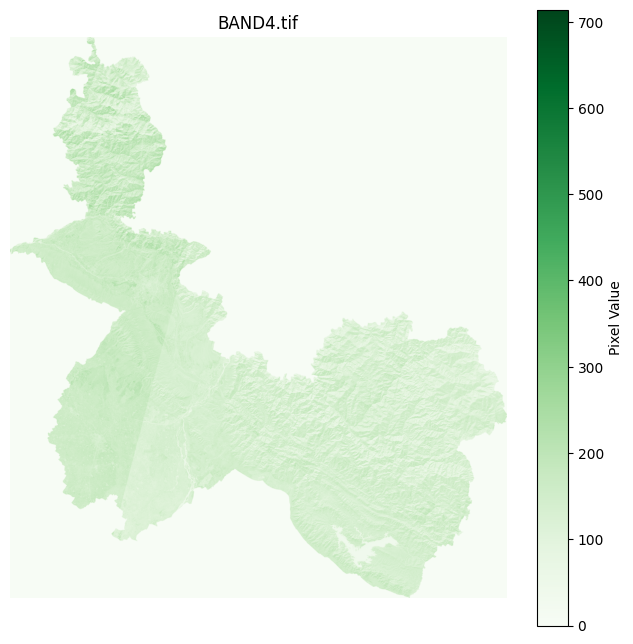

In [4]:
import matplotlib.pyplot as plt

with rasterio.open(sample) as src:
    image = src.read(1)

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap="Greens")
plt.title(sample.name)
plt.colorbar(label="Pixel Value")
plt.axis("off")
plt.show()